In [11]:
###############################################################################
# SEPARATE CELL: STATISTICAL SIGNIFICANCE TEST FOR BOTH AUC AND MCC
# (Uses final_table for real metrics, random_aucs/random_mccs for random)
###############################################################################
import numpy as np
from math import erf, sqrt

def significance_test_random_vs_real(
    real_metrics: dict, 
    random_metrics: dict, 
    metric_name: str
):
    """
    Performs a one-tailed significance test comparing
    the actual model's metric (e.g. AUC or MCC) vs. random sets.

    Parameters:
    -----------
    real_metrics   : dict of {model_name: real_metric_value}
    random_metrics : dict of {model_name: list_of_random_metric_values}
    metric_name    : str, e.g. 'AUC' or 'MCC' for display

    Returns:
    --------
    None (prints the results)
    """

    print(f"\n=== Significance Test for {metric_name} (One-Tail Z-Test) ===")
    for model_name, real_val in real_metrics.items():
        if model_name not in random_metrics:
            print(f"{model_name}: No random {metric_name} found => skipping.")
            continue

        rand_array = np.array(random_metrics[model_name])
        if len(rand_array) == 0:
            print(f"{model_name}: random {metric_name} list is empty => skipping.")
            continue

        mean_rand = rand_array.mean()
        std_rand = rand_array.std(ddof=1)  # sample std
        if std_rand < 1e-9:
            print(f"{model_name}: random {metric_name} stdev ~ 0 => can't do significance test.")
            continue

        # Z-score = ( real_val - mean_rand ) / std_rand
        Z = (real_val - mean_rand) / std_rand

        # One-tail p-value => p = 0.5 * [1 - erf(Z / sqrt(2))]
        p_value = 0.5 * (1.0 - erf(Z / sqrt(2)))

        print(f"{model_name}: Real {metric_name}={real_val:.3f}, "
              f"Random mean={mean_rand:.3f}±{std_rand:.3f}, "
              f"Z={Z:.2f}, p≈{p_value:.5f}")


# EXAMPLE USAGE:
# 1) Gather real AUC & MCC from final_table
real_aucs = {}
real_mccs = {}

for model_name in final_table.index:
    # "ROC_AUC" and "MCC" are the columns in final_table for real metrics
    real_aucs[model_name] = final_table.loc[model_name, "ROC_AUC"]
    real_mccs[model_name] = final_table.loc[model_name, "MCC"]

# 2) Run the significance test (assuming random_aucs / random_mccs exist)
significance_test_random_vs_real(real_aucs, random_aucs, metric_name="AUC")
significance_test_random_vs_real(real_mccs, random_mccs, metric_name="MCC")



=== Significance Test for AUC (One-Tail Z-Test) ===
RandomForest: Real AUC=0.741, Random mean=0.486±0.154, Z=1.66, p≈0.04891
LogisticRegression: Real AUC=0.593, Random mean=0.496±0.237, Z=0.41, p≈0.34217
SVM: Real AUC=0.444, Random mean=0.526±0.137, Z=-0.60, p≈0.72451
KNN: Real AUC=0.722, Random mean=0.456±0.215, Z=1.24, p≈0.10808

=== Significance Test for MCC (One-Tail Z-Test) ===
RandomForest: Real MCC=0.522, Random mean=-0.018±0.286, Z=1.89, p≈0.02953
LogisticRegression: Real MCC=0.258, Random mean=-0.021±0.341, Z=0.82, p≈0.20629
SVM: Real MCC=0.000, Random mean=-0.025±0.266, Z=0.09, p≈0.46314
KNN: Real MCC=0.098, Random mean=-0.086±0.367, Z=0.50, p≈0.30830


In [13]:
###############################################################################
# SEPARATE CELL: GROUPED BAR CHART FOR BJAR CLASSIFICATION
#  - Compares random vs. actual MCC for each classifier
#  - Compares random vs. actual AUC for each classifier
###############################################################################
import numpy as np
import matplotlib.pyplot as plt

def plot_random_vs_actual_bars(final_table):
    """
    Produces two grouped bar charts:
      1) MCC: Random mean vs. Actual
      2) AUC:  Random mean vs. Actual
    Each classifier gets two bars side by side.
    
    Requires final_table to have columns:
      ["MCC", "ROC_AUC", "RandMCC_mean", "RandAUC_mean"]
    and index of classifier names.
    """

    model_names = final_table.index.to_list()
    # For MCC
    actual_mcc = final_table["MCC"].values
    random_mcc = final_table["RandMCC_mean"].values
    
    # For AUC
    actual_auc = final_table["ROC_AUC"].values
    random_auc = final_table["RandAUC_mean"].values

    x = np.arange(len(model_names))  # positions on x-axis
    width = 0.35  # width of each bar

    # --- 1) MCC Bar Chart ---
    fig, ax = plt.subplots(figsize=(8,5))
    rects1 = ax.bar(x - width/2, random_mcc, width, label='Random MCC', color='lightblue')
    rects2 = ax.bar(x + width/2, actual_mcc, width, label='Actual MCC', color='salmon')

    ax.set_xticks(x)
    ax.set_xticklabels(model_names)
    ax.set_ylabel("MCC")
    ax.set_title("Comparison of Random vs. Actual MCC by Classifier")
    ax.legend()

    # Optionally, add numeric labels on top of bars:
    for rect in rects1 + rects2:
        height = rect.get_height()
        ax.annotate(f"{height:.2f}",
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3),  # offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()

    # --- 2) AUC Bar Chart ---
    fig, ax = plt.subplots(figsize=(8,5))
    rects3 = ax.bar(x - width/2, random_auc, width, label='Random AUC', color='lightgreen')
    rects4 = ax.bar(x + width/2, actual_auc, width, label='Actual AUC', color='orange')

    ax.set_xticks(x)
    ax.set_xticklabels(model_names)
    ax.set_ylabel("AUC")
    ax.set_title("Comparison of Random vs. Actual AUC by Classifier")
    ax.legend()

    # Optionally, add numeric labels on top of bars:
    for rect in rects3 + rects4:
        height = rect.get_height()
        ax.annotate(f"{height:.2f}",
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()

# Example usage after your classification cell:
# plot_random_vs_actual_bars(final_table)


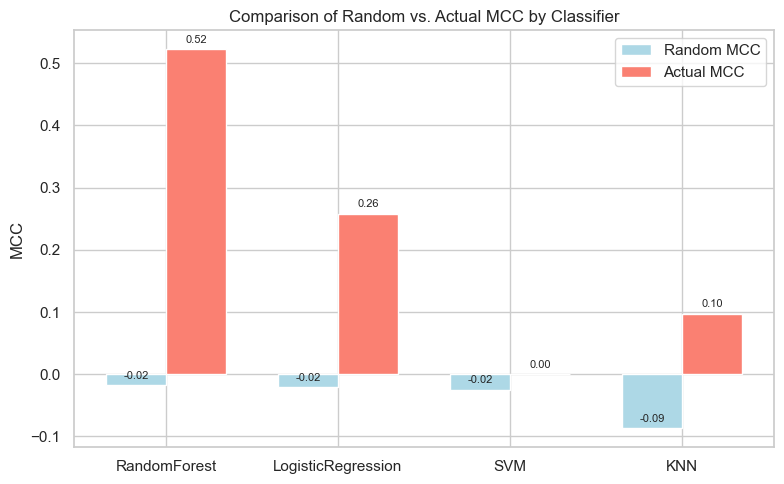

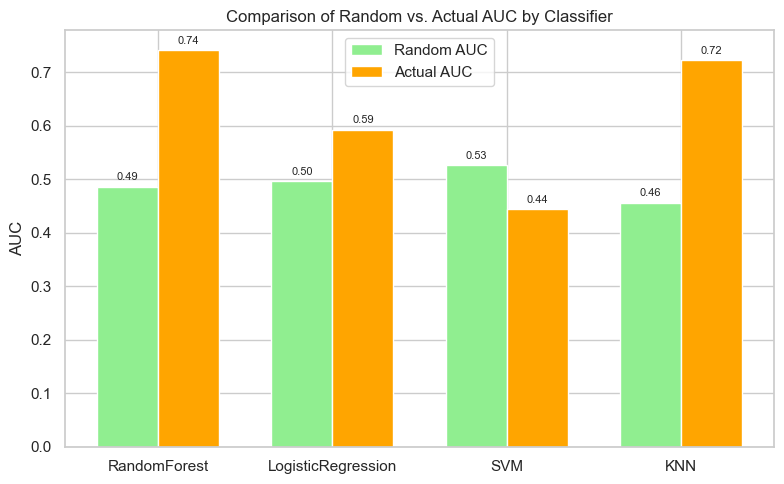

In [14]:
# 1) Make sure you ran the cell that defines plot_random_vs_actual_bars
# 2) Then call:
plot_random_vs_actual_bars(final_table)


[22:47:27] DEPRECATION WARNING: please use MorganGenerator
[22:47:27] DEPRECATION WARNING: please use MorganGenerator
[22:47:27] DEPRECATION WARNING: please use MorganGenerator
[22:47:27] DEPRECATION WARNING: please use MorganGenerator
[22:47:27] DEPRECATION WARNING: please use MorganGenerator
[22:47:27] DEPRECATION WARNING: please use MorganGenerator
[22:47:27] DEPRECATION WARNING: please use MorganGenerator
[22:47:27] DEPRECATION WARNING: please use MorganGenerator
[22:47:27] DEPRECATION WARNING: please use MorganGenerator
[22:47:27] DEPRECATION WARNING: please use MorganGenerator
[22:47:27] DEPRECATION WARNING: please use MorganGenerator
[22:47:27] DEPRECATION WARNING: please use MorganGenerator
[22:47:27] DEPRECATION WARNING: please use MorganGenerator
[22:47:27] DEPRECATION WARNING: please use MorganGenerator
[22:47:27] DEPRECATION WARNING: please use MorganGenerator
[22:47:27] DEPRECATION WARNING: please use MorganGenerator
[22:47:27] DEPRECATION WARNING: please use MorganGenerat

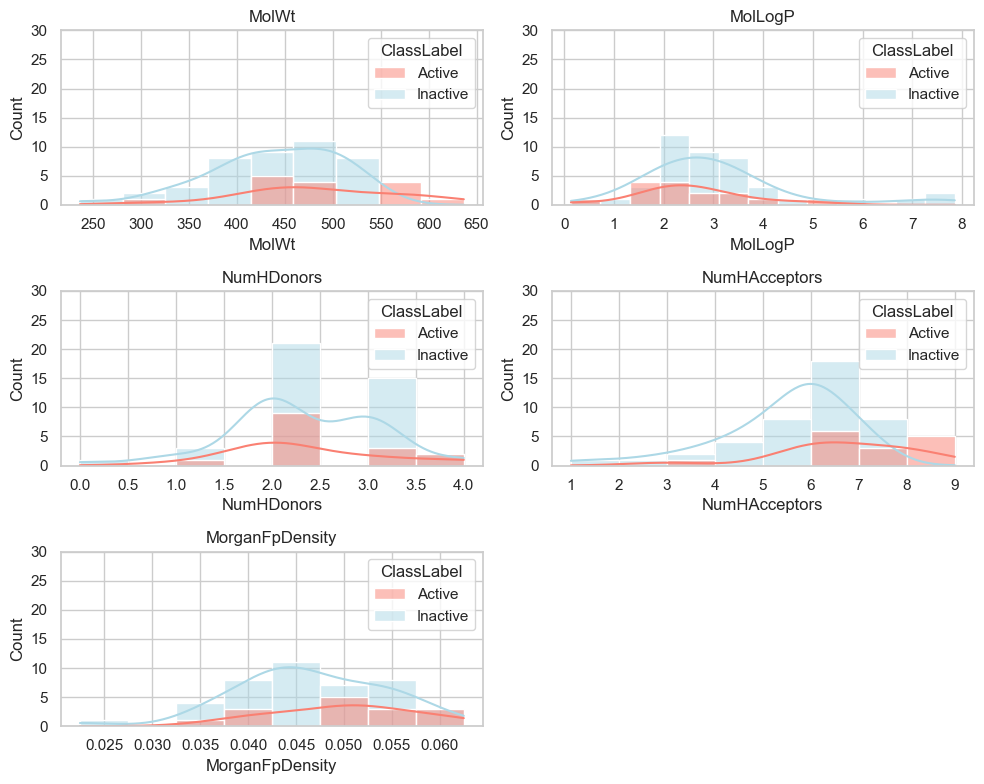

c:\Users\hllpacke\.conda\envs\cheminformatics\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


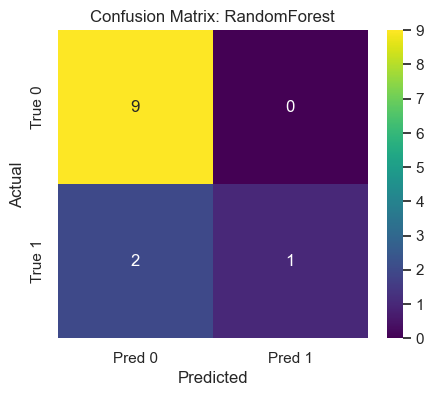

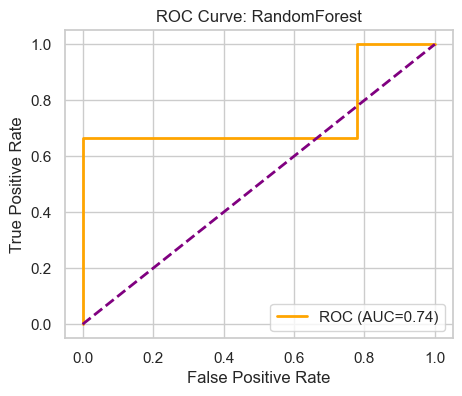

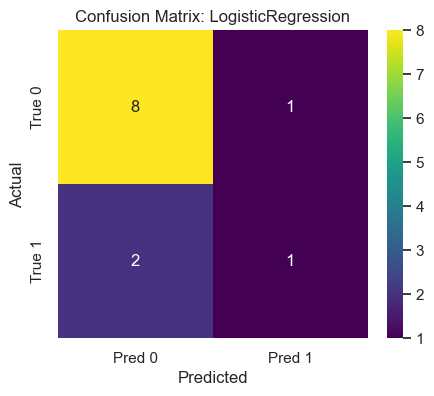

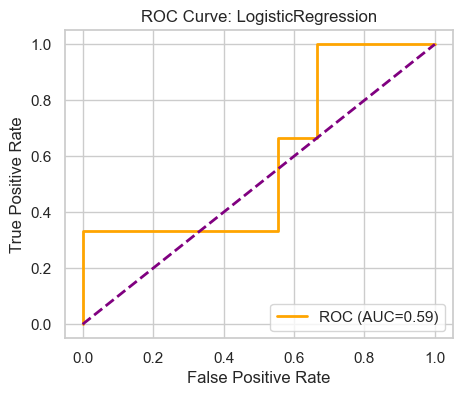

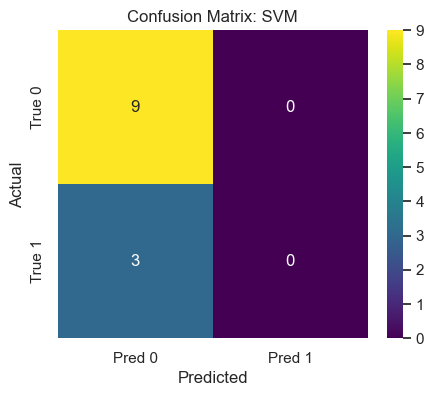

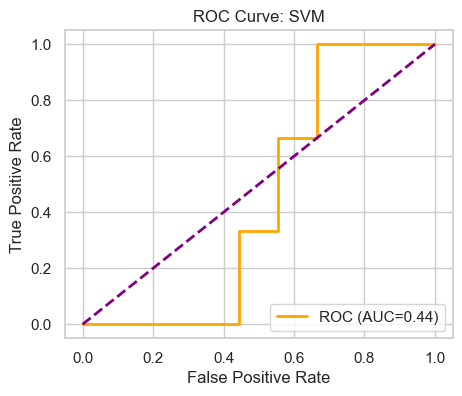

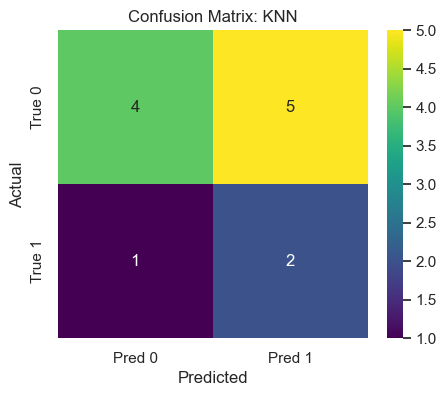

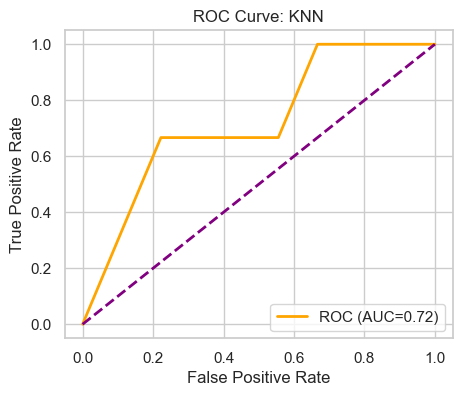


=== Y-RANDOMISED RESULTS (50 permutations) ===
RandomForest: mean AUC=0.472 ± 0.168, mean MCC=-0.041 ± 0.332
LogisticRegression: mean AUC=0.533 ± 0.250, mean MCC=0.037 ± 0.322
SVM: mean AUC=0.543 ± 0.163, mean MCC=-0.073 ± 0.272
KNN: mean AUC=0.460 ± 0.210, mean MCC=-0.021 ± 0.323

=== COMBINED TABLE: REAL vs. RANDOM AUC & MCC ===


,Accuracy,ROC_AUC,MCC,DescriptorModel,RandAUC_mean,RandAUC_std,RandMCC_mean,RandMCC_std
RandomForest,0.833333,0.740741,0.522233,Refined,0.472222,0.168437,-0.041041,0.331627
LogisticRegression,0.750000,0.592593,0.258199,Refined,0.532593,0.250420,0.036600,0.322245
SVM,0.750000,0.444444,0.000000,Refined,0.542963,0.163486,-0.073301,0.272386
KNN,0.500000,0.722222,0.097590,Refined,0.460000,0.210244,-0.020646,0.322589


,Accuracy,ROC_AUC,MCC,DescriptorModel,RandAUC_mean,RandAUC_std,RandMCC_mean,RandMCC_std
RandomForest,0.833333,0.740741,0.522233,Refined,0.472222,0.168437,-0.041041,0.331627
LogisticRegression,0.750000,0.592593,0.258199,Refined,0.532593,0.250420,0.036600,0.322245
SVM,0.750000,0.444444,0.000000,Refined,0.542963,0.163486,-0.073301,0.272386
KNN,0.500000,0.722222,0.097590,Refined,0.460000,0.210244,-0.020646,0.322589


C:\Users\hllpacke\AppData\Local\Temp\ipykernel_10720\3577787120.py:320: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=final_table, x="DescriptorModel", y="ROC_AUC", palette="viridis")


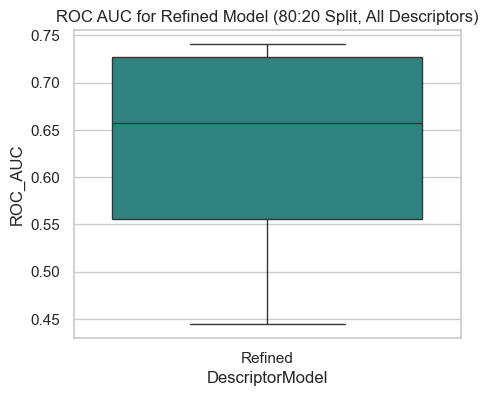


=== RandomForest Feature Importance (scikit-learn) ===


,Feature,RF_Importance
36,PEOE_VSA8,0.063157
39,SMR_VSA10,0.037759
44,SMR_VSA6,0.035075
11,BCUT2D_MWHI,0.033777
17,BCUT2D_MRHI,0.030943
...,...,...
162,fr_quatN,0.000000
165,fr_term_acetylene,0.000000
166,fr_tetrazole,0.000000
167,fr_thiazole,0.000000


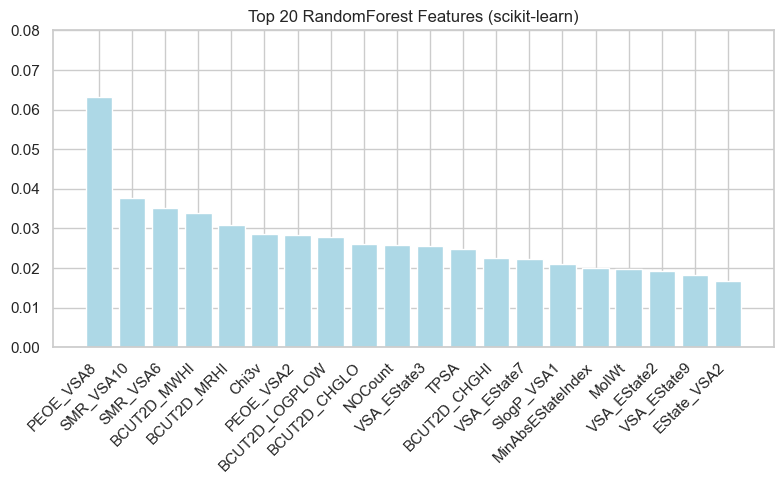

  0%|          | 0/12 [00:00<?, ?it/s]

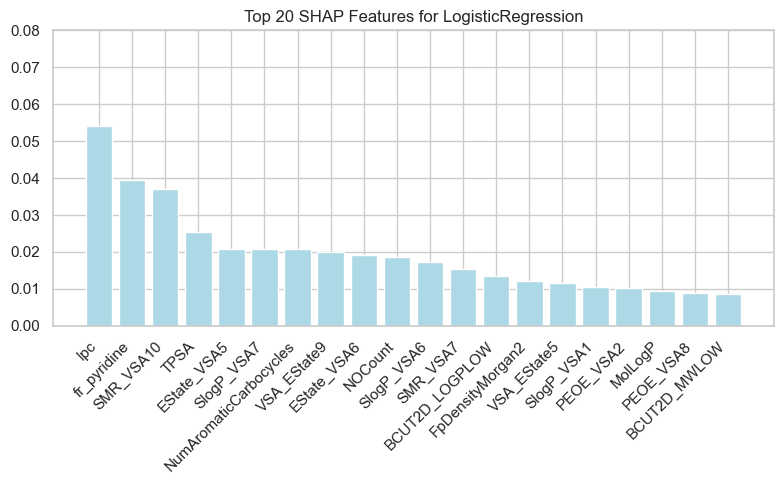

  0%|          | 0/12 [00:00<?, ?it/s]

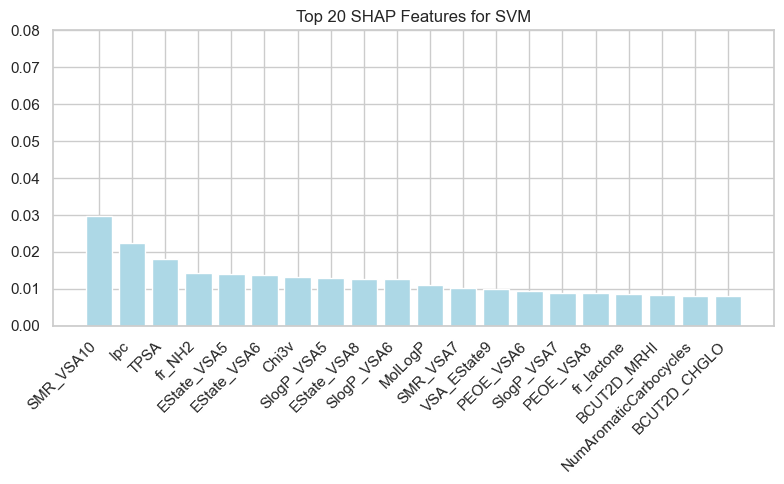

  0%|          | 0/12 [00:00<?, ?it/s]

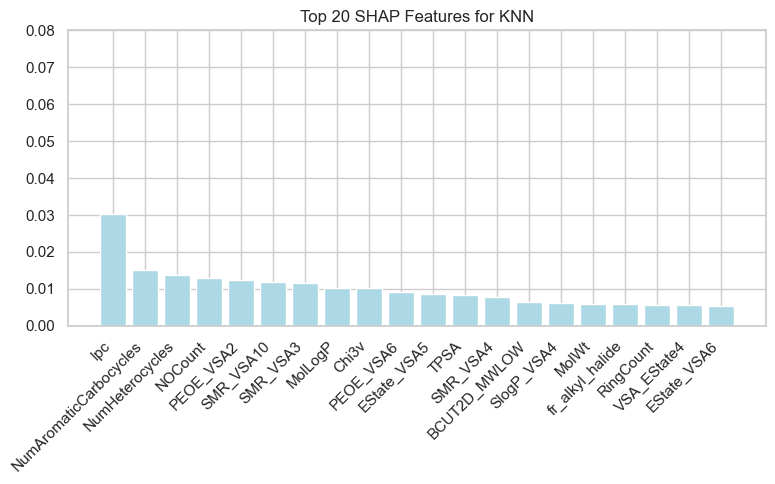


=== Combined Feature Importance Table (All Descriptors) ===


,Feature,RF_Importance,Logistic_SHAP,SVM_SHAP,KNN_SHAP
64,PEOE_VSA8,0.063157,0.008949,0.008808,0.001665
68,SMR_VSA10,0.037759,0.037050,0.029708,0.011797
73,SMR_VSA6,0.035075,0.000000,0.000000,0.001747
7,BCUT2D_MWHI,0.033777,0.000000,0.000000,0.000000
5,BCUT2D_MRHI,0.030943,0.000000,0.008354,0.001764
...,...,...,...,...,...
162,fr_quatN,0.000000,0.000000,0.000000,0.000000
165,fr_term_acetylene,0.000000,0.000000,0.000000,0.000000
166,fr_tetrazole,0.000000,0.000000,0.000000,0.000000
167,fr_thiazole,0.000000,0.000000,0.000000,0.000000



Done! You have:
- A classification pipeline (80:20, SMOTE, correlation removal).
- Confusion matrices & ROC curves for each classifier.
- 5 basic descriptor histograms with y-axis up to 30.
- scikit-learn RandomForest importance with top 20 bar chart (y-axis forced 0..0.08).
- SHAP bar charts (top 20) for Logistic, SVM, KNN, also forced y-axis 0..0.08.
- A final table 'final_table' with real vs. random AUC & MCC for each model, plus returned random_aucs, random_mccs.


In [2]:
###############################################################################
# SINGLE CELL: CLASSIFICATION WORKFLOW + 5 BASIC DESCRIPTOR HISTOGRAMS (y-axis 0..30),
# + SCALING, SMOTE, CORRELATION REMOVAL, MULTIPLE CLASSIFIERS,
# + SCIKIT-LEARN FEATURE IMPORTANCE (RF), SHAP FOR Logistic/SVM/KNN,
# + SEPARATE PLOTS SHOWING TOP 20 FEATURES (y-axis forced 0..0.08),
# + COMBINED TABLE FOR ALL FEATURES
# ADDED: RANDOMISED MCC & AUC, COMBINED TABLE
# FIXED: remove_corr_features to use corr_matrix.shape
###############################################################################

import os
import zipfile
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# RDKit
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem.Descriptors import _descList

# scikit-learn & imblearn
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix, roc_curve,
    classification_report, matthews_corrcoef
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# SHAP for feature importance
import shap
shap.initjs()

sns.set(style='whitegrid')

###############################################################################
# 1. Load Data & Compute RDKit Descriptors
###############################################################################
zip_path = r"M:\CHEM380\CHEM380\Project Data\SVMP_IC50_data.zip"
extract_dir = "./extracted_svmp"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_dir)

df_path = os.path.join(extract_dir, "BJAR.csv")
df = pd.read_csv(df_path)
df.columns = [c.strip() for c in df.columns]

# Suppose "CA_IC50_Activity" is the classification label
if "BJAR_IC50_2Activity" in df.columns:
    df.rename(columns={"BJAR_IC50_2Activity": "Activity"}, inplace=True)
else:
    df.rename(columns={df.columns[1]: "Activity"}, inplace=True)
if "Smiles" in df.columns:
    df.rename(columns={"Smiles": "SMILES"}, inplace=True)

df = df[['SMILES','Activity']].dropna()
df['Activity'] = df['Activity'].astype(float).astype(int)

def compute_all_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    desc_vals = {}
    for (desc_name, desc_func) in _descList:
        desc_vals[desc_name] = desc_func(mol)
    # Morgan fingerprint density
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, 1024)
    arr = np.zeros((1024,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    desc_vals["MorganFpDensity"] = np.sum(arr)/1024
    return desc_vals

desc_list = []
for _, row in df.iterrows():
    dvals = compute_all_descriptors(row['SMILES'])
    desc_list.append(dvals)

df_desc = pd.DataFrame(desc_list)
df_desc['Activity'] = df['Activity'].values
df_desc.dropna(inplace=True)

###############################################################################
# 2. Plot 5 Basic Descriptors (Histograms) with y-axis up to 30
###############################################################################
five_cols = ["MolWt","MolLogP","NumHDonors","NumHAcceptors","MorganFpDensity"]
df_desc['ClassLabel'] = df_desc['Activity'].map({0: 'Inactive', 1: 'Active'})
df_plot = df_desc[five_cols + ['ClassLabel']].dropna()

plt.figure(figsize=(10, 8))
for i, col in enumerate(five_cols, 1):
    plt.subplot(3, 2, i)
    sns.histplot(data=df_plot, x=col, hue='ClassLabel', kde=True,
                 palette={'Inactive':'lightblue','Active':'salmon'})
    plt.title(col)
    plt.ylim(0, 30)  # Force y-axis from 0..30
    plt.yticks(np.arange(0, 31, 5))
plt.tight_layout()
plt.show()

###############################################################################
# 3. Helper Functions
###############################################################################
def remove_corr_features(X, corr_thresh=0.9):
    df_temp = pd.DataFrame(X)
    corr_matrix = df_temp.corr().abs()
    # FIX: use corr_matrix.shape for np.triu
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    to_drop = [col for col in upper.columns if any(upper[col] > corr_thresh)]
    keep_cols = np.setdiff1d(np.arange(X.shape[1]), to_drop)
    return keep_cols

def remove_offset_columns(shap_values_array, num_features):
    """
    Repeatedly slice off columns if shap_values_array has more columns than num_features.
    """
    while shap_values_array.shape[1] > num_features:
        shap_values_array = shap_values_array[:, :-1]
    return shap_values_array

def compute_shap_table(model, X_train, X_test, feature_names, shap_label):
    """
    Returns a DataFrame ["Feature", shap_label] of mean abs SHAP for class=1.
    Fixes shape mismatch if needed.
    """
    background = X_train[np.random.choice(X_train.shape[0], 50, replace=False)]
    explainer = shap.KernelExplainer(lambda x: model.predict_proba(x)[:, 1], background)
    shap_values = explainer.shap_values(X_test)
    shap_values = remove_offset_columns(shap_values, X_test.shape[1])
    mean_abs_shap = np.mean(np.abs(shap_values), axis=0)
    if len(mean_abs_shap) != len(feature_names):
        raise ValueError(f"Length mismatch: mean_abs_shap={len(mean_abs_shap)} vs feature_names={len(feature_names)}")
    df_shap = pd.DataFrame({
        "Feature": feature_names,
        shap_label: mean_abs_shap
    })
    return df_shap

def plot_confusion_and_roc(model_name, y_test, y_proba, y_pred):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
                xticklabels=['Pred 0','Pred 1'],
                yticklabels=['True 0','True 1'])
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    if y_proba is not None:
        auc_val = roc_auc_score(y_test, y_proba)
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.figure(figsize=(5,4))
        plt.plot(fpr, tpr, color='orange', lw=2, label=f"ROC (AUC={auc_val:.2f})")
        plt.plot([0,1],[0,1], color='purple', lw=2, linestyle='--')
        plt.title(f"ROC Curve: {model_name}")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend(loc="lower right")
        plt.show()

###############################################################################
# 4. Classification Workflow (80:20, SMOTE, Corr Removal, etc.)
###############################################################################
def classification_workflow(df_desc):
    from sklearn.model_selection import train_test_split
    from imblearn.over_sampling import SMOTE
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import roc_auc_score, accuracy_score, matthews_corrcoef

    original_feature_names = [c for c in df_desc.columns if c not in ("Activity","ClassLabel")]

    X_all = df_desc.drop(columns=["Activity","ClassLabel"], errors="ignore").values
    y_all = df_desc["Activity"].values

    # 80:20 split
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
    )

    # SMOTE
    sm = SMOTE(random_state=42)
    X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_bal)
    X_test_scaled  = scaler.transform(X_test)

    # Remove correlated features => refined
    keep_cols = remove_corr_features(X_train_scaled, corr_thresh=0.9)
    X_train_final = X_train_scaled[:, keep_cols]
    X_test_final  = X_test_scaled[:, keep_cols]

    feature_names = [original_feature_names[i] for i in keep_cols]

    # Define classifiers
    models = {
        "RandomForest": RandomForestClassifier(random_state=42, class_weight='balanced'),
        "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
        "SVM": SVC(probability=True, random_state=42, class_weight='balanced'),
        "KNN": KNeighborsClassifier()
    }

    # Train & evaluate real models
    results = {}
    trained_models = {}

    for name, clf in models.items():
        clf.fit(X_train_final, y_train_bal)
        trained_models[name] = clf

        y_pred = clf.predict(X_test_final)
        if hasattr(clf, "predict_proba"):
            y_proba = clf.predict_proba(X_test_final)[:, 1]
            auc_val = roc_auc_score(y_test, y_proba)
        else:
            y_proba = None
            auc_val = float('nan')

        acc_val = accuracy_score(y_test, y_pred)
        mcc_val = matthews_corrcoef(y_test, y_pred)

        results[name] = {
            "Accuracy": acc_val,
            "ROC_AUC": auc_val,
            "MCC": mcc_val
        }

        plot_confusion_and_roc(name, y_test, y_proba, y_pred)

    df_results = pd.DataFrame(results).T
    df_results["DescriptorModel"] = "Refined"

    # --- Y-RANDOMISATION (AUC & MCC) ---
    num_random = 50
    random_aucs = {m: [] for m in models.keys()}
    random_mccs = {m: [] for m in models.keys()}

    for i in range(num_random):
        y_shuffled = np.random.permutation(y_train_bal)

        for model_name in models:
            if model_name == "RandomForest":
                clf_rand = RandomForestClassifier(random_state=42, class_weight='balanced')
            elif model_name == "LogisticRegression":
                clf_rand = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
            elif model_name == "SVM":
                clf_rand = SVC(probability=True, random_state=42, class_weight='balanced')
            elif model_name == "KNN":
                clf_rand = KNeighborsClassifier()

            # Fit on shuffled labels
            clf_rand.fit(X_train_final, y_shuffled)

            # Evaluate on real test set
            y_pred_rand = clf_rand.predict(X_test_final)
            if hasattr(clf_rand, "predict_proba"):
                y_proba_rand = clf_rand.predict_proba(X_test_final)[:, 1]
                auc_rand = roc_auc_score(y_test, y_proba_rand)
            else:
                auc_rand = float('nan')

            mcc_rand = matthews_corrcoef(y_test, y_pred_rand)

            random_aucs[model_name].append(auc_rand)
            random_mccs[model_name].append(mcc_rand)

    print("\n=== Y-RANDOMISED RESULTS (50 permutations) ===")
    random_rows = []
    for model_name in models:
        arr_auc = np.array(random_aucs[model_name])
        arr_mcc = np.array(random_mccs[model_name])
        mean_auc, std_auc = arr_auc.mean(), arr_auc.std()
        mean_mcc, std_mcc = arr_mcc.mean(), arr_mcc.std()
        print(f"{model_name}: mean AUC={mean_auc:.3f} ± {std_auc:.3f}, mean MCC={mean_mcc:.3f} ± {std_mcc:.3f}")
        random_rows.append({
            "Model": model_name,
            "RandAUC_mean": mean_auc,
            "RandAUC_std": std_auc,
            "RandMCC_mean": mean_mcc,
            "RandMCC_std": std_mcc
        })

    random_df = pd.DataFrame(random_rows).set_index("Model")

    # Combine real & random into one final table
    final_table = df_results.join(random_df, how='left')
    print("\n=== COMBINED TABLE: REAL vs. RANDOM AUC & MCC ===")
    display(final_table)

    # Return random_aucs, random_mccs so we can do significance test later
    return final_table, trained_models, feature_names, X_train_final, X_test_final, random_aucs, random_mccs

###############################################################################
# 5. Run the Classification Workflow
###############################################################################
df_desc.dropna(inplace=True)

(final_table,
 trained_models,
 feature_names,
 X_train_final,
 X_test_final,
 random_aucs,
 random_mccs) = classification_workflow(df_desc)

display(final_table)

plt.figure(figsize=(5,4))
sns.boxplot(data=final_table, x="DescriptorModel", y="ROC_AUC", palette="viridis")
plt.title("ROC AUC for Refined Model (80:20 Split, All Descriptors)")
plt.show()

###############################################################################
# 6. Feature Importance:
#    - scikit-learn for RandomForest
#    - SHAP for Logistic, SVM, KNN
#    - Show top 20 features, forcing y-axis range (0..0.08),
#    - Combined table includes all descriptors
###############################################################################

rf = trained_models["RandomForest"]
rf_importances = rf.feature_importances_

df_rf_import = pd.DataFrame({
    "Feature": feature_names,
    "RF_Importance": rf_importances
}).sort_values("RF_Importance", ascending=False)

print("\n=== RandomForest Feature Importance (scikit-learn) ===")
display(df_rf_import)

# Plot top 20 descriptors for RandomForest (force y-axis from 0..0.08)
top_n_rf = min(20, len(df_rf_import))
df_rf_top20 = df_rf_import.iloc[:top_n_rf]

plt.figure(figsize=(8,5))
plt.title("Top 20 RandomForest Features (scikit-learn)")
plt.bar(range(top_n_rf), df_rf_top20["RF_Importance"], color='lightblue', align='center')
plt.xticks(range(top_n_rf), df_rf_top20["Feature"], rotation=45, ha='right')
plt.ylim(0,0.08)  # force same y-axis range for demonstration
plt.tight_layout()
plt.show()

df_combined = df_rf_import.copy()
df_combined.reset_index(drop=True, inplace=True)

def shap_table_and_plot_top20(model, model_name, shap_label, y_min=0, y_max=0.08):
    df_shap = compute_shap_table(model, X_train_final, X_test_final, feature_names, shap_label)
    # Sort & plot top 20
    df_sorted = df_shap.sort_values(shap_label, ascending=False)
    top_n = min(20, len(df_sorted))
    df_top20 = df_sorted.iloc[:top_n]

    plt.figure(figsize=(8,5))
    plt.title(f"Top 20 SHAP Features for {model_name}")
    plt.bar(range(top_n), df_top20[shap_label], color='lightblue', align='center')
    plt.xticks(range(top_n), df_top20["Feature"], rotation=45, ha='right')
    plt.ylim(y_min, y_max)  # same y-axis range (0..0.08)
    plt.tight_layout()
    plt.show()

    return df_shap

for model_name, shap_label in [
    ("LogisticRegression", "Logistic_SHAP"),
    ("SVM", "SVM_SHAP"),
    ("KNN", "KNN_SHAP")
]:
    model = trained_models.get(model_name)
    if model is not None and hasattr(model, "predict_proba"):
        df_shap = shap_table_and_plot_top20(model, model_name, shap_label, y_min=0, y_max=0.08)
        df_combined = pd.merge(df_combined, df_shap, on="Feature", how="outer")
    else:
        print(f"Model {model_name} not found or lacks predict_proba => skipping SHAP.")

df_combined.fillna(0, inplace=True)
df_combined.sort_values("RF_Importance", ascending=False, inplace=True)

print("\n=== Combined Feature Importance Table (All Descriptors) ===")
display(df_combined)

print("\nDone! You have:")
print("- A classification pipeline (80:20, SMOTE, correlation removal).")
print("- Confusion matrices & ROC curves for each classifier.")
print("- 5 basic descriptor histograms with y-axis up to 30.")
print("- scikit-learn RandomForest importance with top 20 bar chart (y-axis forced 0..0.08).")
print("- SHAP bar charts (top 20) for Logistic, SVM, KNN, also forced y-axis 0..0.08.")
print("- A final table 'final_table' with real vs. random AUC & MCC for each model, plus returned random_aucs, random_mccs.")
